In [1]:
# Setup
# Cell 1: Setup
import data_loader
import importlib
importlib.reload(data_loader)


# print(f"Box size1: {BOX_SIZE}")

# Setup
from data_loader import *
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

print("BOX_SIZE2:", BOX_SIZE)


plt.rcParams.update({'font.size': 14})


def autocorr(x, max_lag):
    """
    Normalized autocorrelation function C(tau)
    """
    x = np.asarray(x)
    x = x - x.mean()
    var = np.mean(x**2)

    acf = np.zeros(max_lag)
    for tau in range(max_lag):
        acf[tau] = np.mean(x[:-tau or None] * x[tau:]) / var

    return acf

Loading bubble data...
✓ Loaded 139446 observations
✓ Timesteps added: 0 to 725
✓ Identified 300 disappearing bubbles
Applying periodic boundary corrections...
✓ Periodic boundary correction applied
✓ Derived quantities computed

DATA LOADING COMPLETE
Total observations:       139,446
Unique bubbles:           400
Timesteps:                0 to 725
Disappearing bubbles:     300
Box size:                 20.203051
Initial avg area (A_0):   1.000000

Available variables:
  - df: Original dataframe
  - df_corrected: Corrected dataframe with actual_area column
  - disappearing_ids: Set of disappearing bubble IDs
  - bubbles_per_timestep: Number of bubbles at each timestep
  - avg_area_per_timestep: Average bubble area at each timestep
  - approx_avg_area: Approximate area from liquid fraction
  - A_0: Initial average bubble area
  - max_timestep: Maximum timestep
  - final_step: Final timestep
  - box_area: Total box area
  - BOX_SIZE, PERIODIC_THRESHOLD, LIQUID_FRACTION: Constants

Loadin

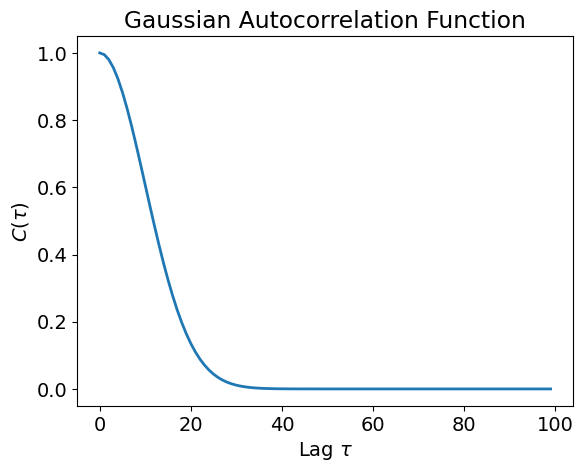

In [2]:
# gaussian autocorrelation function
def gaussian_acf(lags, sigma):
    return np.exp(-lags**2 / (2 * sigma**2))   

lags = np.arange(0, 100)
sigma = 10
acf_gaussian = gaussian_acf(lags, sigma)   
plt.plot(lags, acf_gaussian, lw=2)
plt.xlabel(r"Lag $\tau$")
plt.ylabel(r"$C(\tau)$")
plt.title("Gaussian Autocorrelation Function")
plt.show()